In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/processed/ds_salaries_2025_clean.csv")

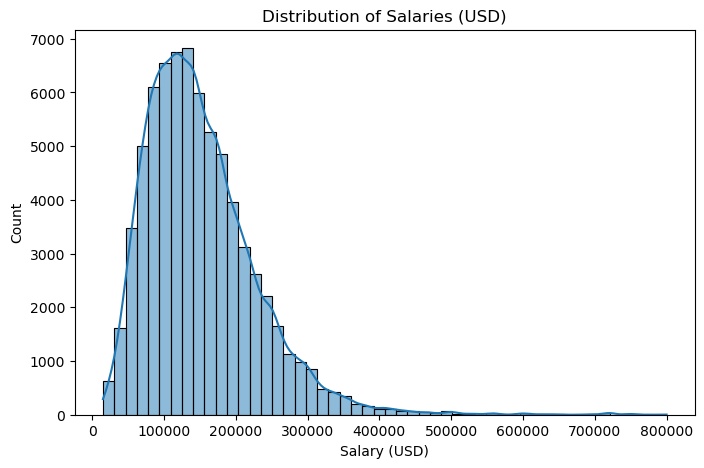

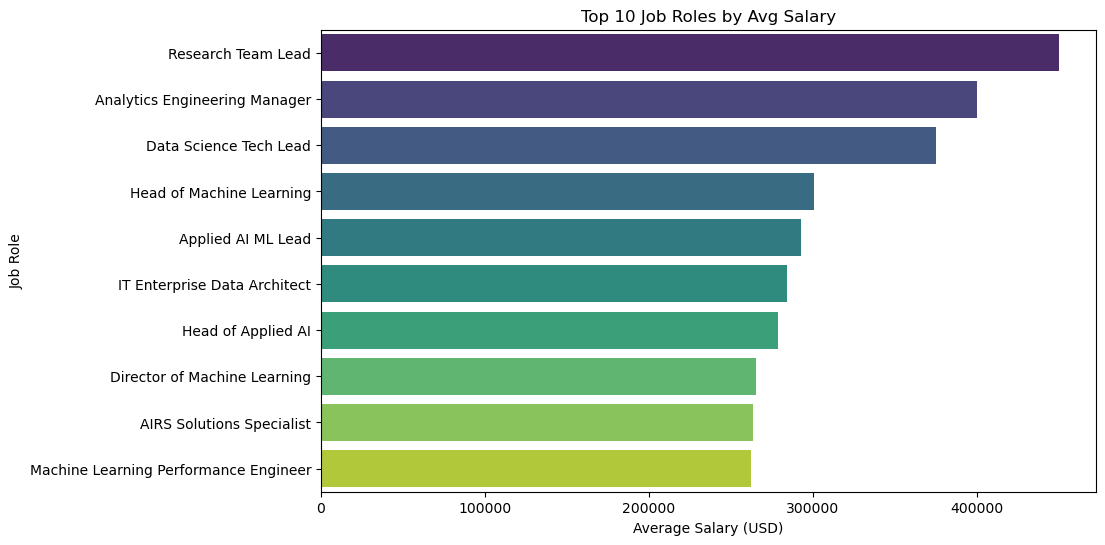

In [15]:
# --------------------------
# 4. First Exploratory Plots
# --------------------------

# Salary distribution
plt.figure(figsize=(8,5))
sns.histplot(df['salary_in_usd'], bins=50, kde=True)
plt.title("Distribution of Salaries (USD)")
plt.xlabel("Salary (USD)")
plt.ylabel("Count")
plt.show()

# Average salary by role
plt.figure(figsize=(10,6))
role_salary = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=role_salary.values, y=role_salary.index, palette="viridis")
plt.title("Top 10 Job Roles by Avg Salary")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Role")
plt.show()

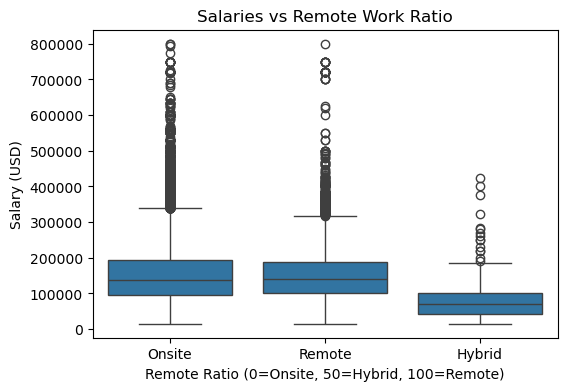

In [16]:
# --------------------------
# 5. Salary by Remote Ratio
# --------------------------

if 'remote_ratio' in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df)
    plt.title("Salaries vs Remote Work Ratio")
    plt.xlabel("Remote Ratio (0=Onsite, 50=Hybrid, 100=Remote)")
    plt.ylabel("Salary (USD)")
    plt.show()

### Salaries vs Remote Work Ratio
- Remote (100) roles show higher variability and some of the highest-paying jobs.
- Hybrid (50) roles generally earn less than both onsite and fully remote roles.
- Remote work offers access to global pay scales, explaining higher outliers.

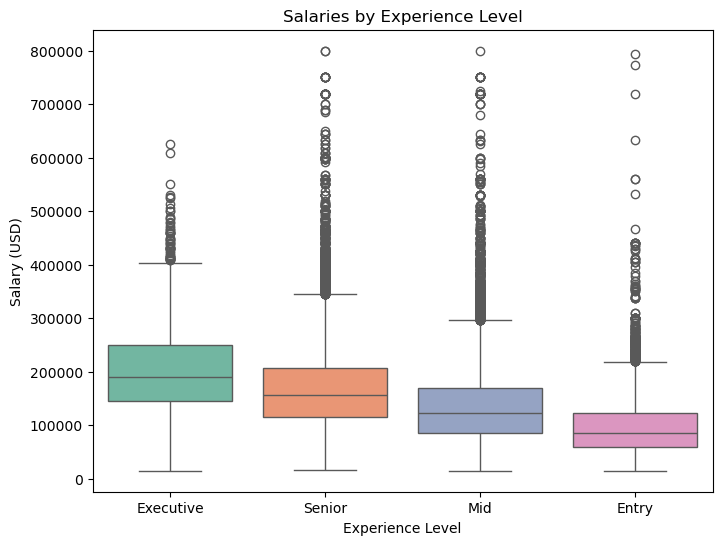

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df, palette="Set2")
plt.title("Salaries by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")
plt.show()

### Salaries by Experience Level
- Clear upward trend: **Executives (EX) > Senior (SE) > Mid (MI) > Entry (EN)**.
- Entry-level salaries cluster at the lower end, while executives show wide spread.
- Outliers represent high-paying senior/executive roles in top markets.

# Step 2: Exploratory Data Analysis (EDA)

In this step, we explore the **Data Science job salaries dataset (2025)** to understand:
- Salary distributions and variation
- How salaries differ by job role, seniority, region, and remote work
- Emerging insights that will guide predictive modeling and NLP analysis later

We’ll use **visualizations and group statistics** to tell the story.

### Salary by Job Title (Top 15 roles)

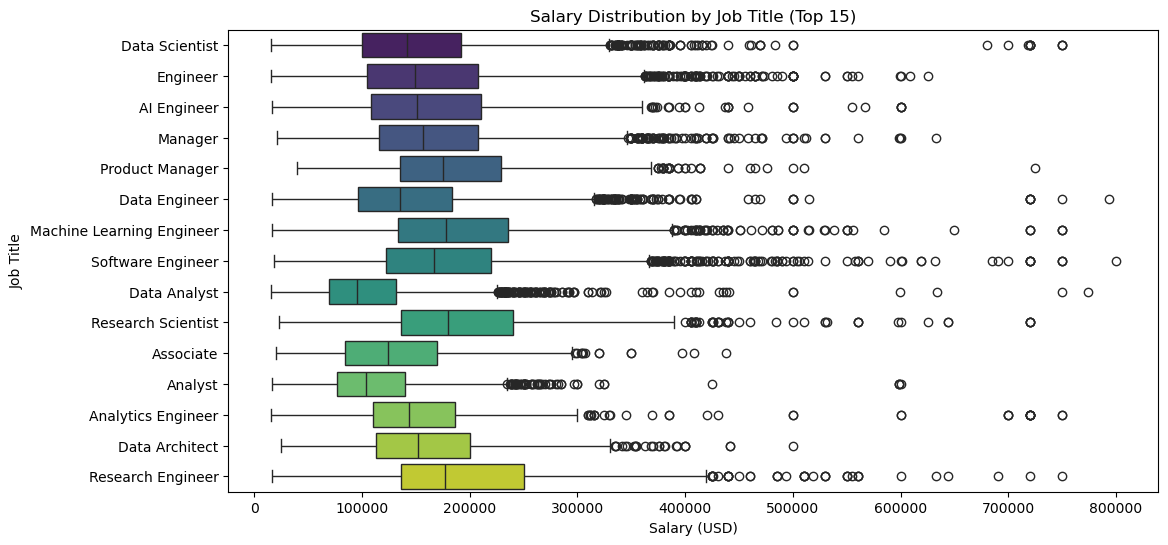

In [18]:
plt.figure(figsize=(12,6))
top_roles = df['job_title'].value_counts().nlargest(15).index
sns.boxplot(y='job_title', x='salary_in_usd', 
            data=df[df['job_title'].isin(top_roles)], palette="viridis")
plt.title("Salary Distribution by Job Title (Top 15)")
plt.xlabel("Salary (USD)")
plt.ylabel("Job Title")
plt.show()

### Salary Distribution by Job Title (Top 15)
- **AI Engineers, ML Engineers, and Data Scientists** dominate top salary brackets.
- Analyst and Associate roles sit at the lower end.
- Job title strongly influences salary range, not just experience.

### Salary by Company Location (Top 10 regions)

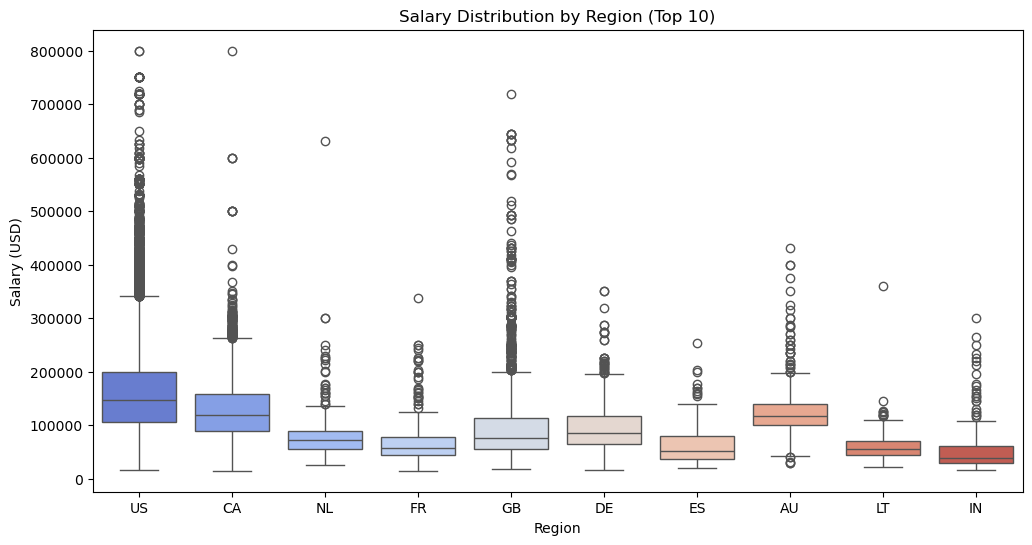

In [19]:
plt.figure(figsize=(12,6))
top_regions = df['company_location'].value_counts().nlargest(10).index
sns.boxplot(x='company_location', y='salary_in_usd', 
            data=df[df['company_location'].isin(top_regions)], palette="coolwarm")
plt.title("Salary Distribution by Region (Top 10)")
plt.xlabel("Region")
plt.ylabel("Salary (USD)")
plt.show()

### Salary Distribution by Region (Top 10)
- The **US consistently leads**, with the widest spread and highest salaries.
- Western Europe (DE, FR, GB, NL) offers mid-to-high salaries.
- Emerging markets (IN, LT, ES) lag significantly, even for senior roles.

### Salary Heatmap (Region vs Seniority; TOP 15)

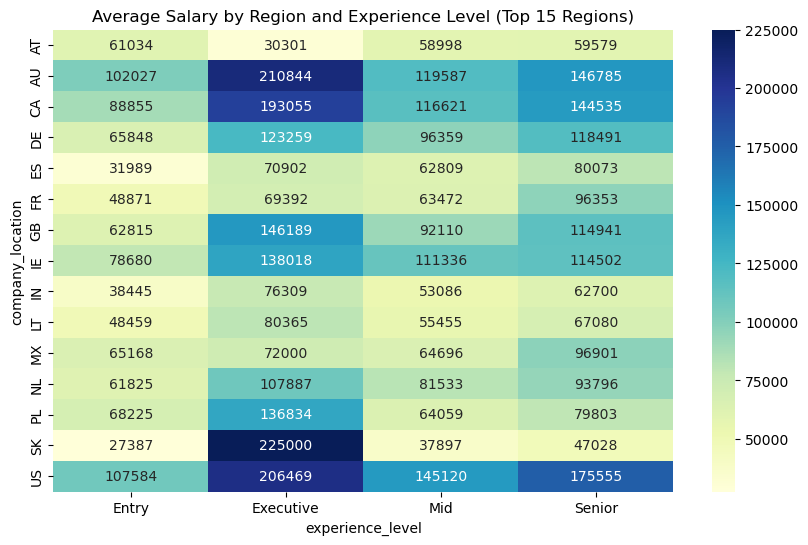

In [20]:
# Pick top 15 regions with most entries
top_regions = df['company_location'].value_counts().nlargest(15).index

pivot = df[df['company_location'].isin(top_regions)].pivot_table(
    values='salary_in_usd', 
    index='company_location', 
    columns='experience_level', 
    aggfunc='mean'
).fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Salary by Region and Experience Level (Top 15 Regions)")
plt.show()

### Average Salary by Region and Experience Level (Heatmap)
- **US, Canada, and Switzerland** offer the highest pay at all levels.
- Emerging markets like **India and Mexico** show large gaps compared to developed regions.
- The gap between **entry-level and executive roles** is widest in US/CA.